# GraphRAG（图增强 RAG）：用“概念图 + 图遍历”补足纯向量检索

纯向量检索（Top‑K chunks）在很多问题上已经足够，但它有一个天然短板：

- 一个答案往往需要**跨多个 chunk 的连接**（多跳关系 / 远距离依赖）
- Top‑K 往往只把“最像”的段落拿回来，未必把“关键连接段落”带回来

GraphRAG 的核心思想是：

1. 仍然用向量检索作为**入口**（找到最相关的起点节点）
2. 把 chunks 组织成一个**知识图**（节点=chunk；边=相似度/共享概念）
3. 在图上做一次“**按相关性优先**”的遍历，把与答案有关的连接节点逐步补齐

<div style="text-align: center;">

<img src="../images/graph_rag.svg" alt="graph RAG" style="width:100%; height:auto;">
</div>


## 0) 环境准备

本 notebook 不包含 `pip install`。请确保：

- 已设置 `OPENAI_API_KEY`（建议放在 `../.env`）
- 已安装：`networkx`、`numpy`、`matplotlib`（可视化可选）、`pypdf`、以及本项目的 LangChain 依赖

In [ ]:
from __future__ import annotations

import math
import os
import re
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np
import networkx as nx
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from pypdf import PdfReader

# 仅做环境初始化；业务变量尽量放到首次使用它们的 cell 里定义
load_dotenv("../.env")
sys.path.insert(0, str(Path("..").resolve()))

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

/tmp/ipykernel_1047200/1273056452.py:26: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [ ]:
os.environ["HTTP_PROXY"] = os.getenv("HTTP_PROXY", "http://127.0.0.1:7890")
os.environ["HTTPS_PROXY"] = os.getenv("HTTPS_PROXY", "http://127.0.0.1:7890")
os.environ["ALL_PROXY"] = os.getenv("ALL_PROXY", "http://127.0.0.1:7890")

## 1) 准备文档：下载 PDF 并切分成 chunks

我们沿用仓库里常用的示例 PDF：`Understanding_Climate_Change.pdf`。


In [3]:
import requests

DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = DATA_DIR / "Understanding_Climate_Change.pdf"
PDF_URL = "https://raw.githubusercontent.com/NirDiamant/RAG_TECHNIQUES/main/data/Understanding_Climate_Change.pdf"


def download_file(url: str, path: Path, timeout_s: int = 60) -> None:
    if path.exists() and path.stat().st_size > 0:
        return
    headers = {"User-Agent": "paper-qa-rag-techniques/1.0"}
    r = requests.get(url, headers=headers, timeout=timeout_s)
    r.raise_for_status()
    path.write_bytes(r.content)


download_file(PDF_URL, PDF_PATH)
PDF_PATH

PosixPath('../data/Understanding_Climate_Change.pdf')

In [4]:
def read_pdf_pages(path: Path) -> list[Document]:
    reader = PdfReader(str(path))
    docs: list[Document] = []
    for i, page in enumerate(reader.pages):
        text = page.extract_text() or ""
        docs.append(Document(page_content=text, metadata={"source": str(path), "page": i}))
    return docs


docs = read_pdf_pages(PDF_PATH)
len(docs), docs[0].metadata

(33, {'source': '../data/Understanding_Climate_Change.pdf', 'page': 0})

In [5]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=120,
    separators=["\n\n", "\n", "。", ".", " ", ""],
)

splits = splitter.split_documents(docs)
len(splits), splits[0].metadata

(121, {'source': '../data/Understanding_Climate_Change.pdf', 'page': 0})

为了控制成本/时延，我们先用一个较小子集来演示图构建与遍历（后面把 `MAX_NODES` 调大即可在更大语料上跑）。


In [6]:
MAX_NODES = 25

graph_docs: list[Document] = []
for i, d in enumerate(splits[:MAX_NODES]):
    # node_id 是关键：向量检索命中 doc 后，我们要能回到图节点
    md = dict(d.metadata)
    md["node_id"] = i
    graph_docs.append(Document(page_content=d.page_content, metadata=md))

len(graph_docs), graph_docs[0].metadata

(25,
 {'source': '../data/Understanding_Climate_Change.pdf',
  'page': 0,
  'node_id': 0})

## 2) 向量库：用于“找到起点节点”

GraphRAG 不是替代向量检索，而是把向量检索当作 **图遍历的起点选择器**。


In [ ]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# 构建向量库（演示用：直接在内存里建；需要持久化可另存 faiss index）
store = FAISS.from_documents(graph_docs, embeddings)
retriever = store.as_retriever(search_kwargs={"k": 3})

## 3) 构建知识图：节点=chunk，边=相似度/共享概念

在原仓库的 GraphRAG 里，概念抽取同时用了：

- **NLP**（例如 NER）抽取命名实体
- **LLM** 抽取一般概念

这里我们保留“**LLM 概念抽取**”作为主线（更贴近 RAG 的语义层），并做一个轻量的概念归一化函数（小写、去噪、简单词形规整）。


In [ ]:
class Concepts(BaseModel):
    concepts_list: list[str] = Field(..., description="从文本中抽取的关键概念/实体短语列表")


def normalize_concept(x: str) -> str:
    x = x.strip().lower()
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[^a-z0-9\-\s]", "", x)
    x = x.strip()

    # 一个非常轻量的“词形规整”：够用即可（目标是更好匹配，而不是做严谨词法学）
    def _norm_token(t: str) -> str:
        if len(t) <= 3:
            return t
        if t.endswith("ies") and len(t) > 4:
            return t[:-3] + "y"
        if t.endswith("sses"):
            return t[:-2]
        if t.endswith("s") and not t.endswith("ss") and len(t) > 3:
            return t[:-1]
        if t.endswith("ing") and len(t) > 5:
            return t[:-3]
        if t.endswith("ed") and len(t) > 4:
            return t[:-2]
        return t

    tokens = [t for t in x.split(" ") if t]
    tokens = [_norm_token(t) for t in tokens]
    return " ".join(tokens)


concept_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "你是一个信息抽取器。任务：从给定文本中抽取 6-12 个‘关键概念/实体短语’。\n"
            "要求：\n"
            "- 概念要偏‘名词短语’，可包含专业术语（例如 greenhouse effect）\n"
            "- 不要输出句子，不要解释\n"
            "- 输出必须符合 JSON schema\n",
        ),
        ("user", "文本：\n{text}"),
    ]
)

concept_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
concept_chain = concept_prompt | concept_llm.with_structured_output(
    Concepts, method="json_schema", strict=True
)

In [9]:
# 用 batch 一次抽取多个节点的概念（比逐条 invoke 更省 overhead）
texts = [d.page_content for d in graph_docs]

concept_results: list[Concepts] = concept_chain.batch(
    [{"text": t} for t in texts],
    config={"max_concurrency": 8},
)

node_concepts: list[list[str]] = []
for r in concept_results:
    concepts = [normalize_concept(c) for c in r.concepts_list]
    concepts = [c for c in concepts if c]
    # 去重但保序
    seen = set()
    uniq: list[str] = []
    for c in concepts:
        if c not in seen:
            seen.add(c)
            uniq.append(c)
    node_concepts.append(uniq)

node_concepts[0][:10]

['climate change',
 'global climate',
 'weather pattern',
 'temperature',
 'precipitation',
 'wind pattern',
 'fossil fuel',
 'deforestation',
 'historical context',
 'glacial advance']

In [10]:
def cosine_sim_matrix(vectors: np.ndarray) -> np.ndarray:
    # vectors: (n, d)
    eps = 1e-12
    norms = np.linalg.norm(vectors, axis=1, keepdims=True) + eps
    v = vectors / norms
    return v @ v.T


chunk_vectors = np.array(embeddings.embed_documents(texts), dtype=np.float32)
sim_mat = cosine_sim_matrix(chunk_vectors)

sim_mat.shape, float(sim_mat[0, 1])

((25, 25), 0.6900669932365417)

In [11]:
@dataclass(frozen=True)
class EdgeInfo:
    weight: float
    similarity: float
    shared_concepts: tuple[str, ...]


def edge_weight(similarity: float, shared_concepts: Iterable[str], c1: list[str], c2: list[str], alpha: float = 0.7, beta: float = 0.3) -> float:
    max_possible_shared = max(1, min(len(c1), len(c2)))
    normalized_shared = len(set(shared_concepts)) / max_possible_shared
    return float(alpha * similarity + beta * normalized_shared)


def build_knowledge_graph(
    docs: list[Document],
    concepts: list[list[str]],
    sim_mat: np.ndarray,
    sim_threshold: float = 0.80,
) -> nx.Graph:
    g = nx.Graph()

    for i, d in enumerate(docs):
        g.add_node(i, content=d.page_content, concepts=concepts[i], metadata=d.metadata)

    n = len(docs)
    for i in range(n):
        for j in range(i + 1, n):
            sim = float(sim_mat[i, j])
            if sim < sim_threshold:
                continue
            shared = tuple(sorted(set(concepts[i]) & set(concepts[j])))
            w = edge_weight(sim, shared, concepts[i], concepts[j])
            g.add_edge(i, j, info=EdgeInfo(weight=w, similarity=sim, shared_concepts=shared))

    return g


SIM_THRESHOLD = 0.80
kg = build_knowledge_graph(graph_docs, node_concepts, sim_mat, sim_threshold=SIM_THRESHOLD)

if kg.number_of_edges() == 0:
    # 图太稀疏时，遍历几乎不会扩展；先自动降一点阈值，保证演示能跑通
    SIM_THRESHOLD = 0.75
    kg = build_knowledge_graph(graph_docs, node_concepts, sim_mat, sim_threshold=SIM_THRESHOLD)

kg.number_of_nodes(), kg.number_of_edges(), SIM_THRESHOLD

(25, 1, 0.8)

如果你发现边太少（图太稀疏），把 `SIM_THRESHOLD` 调低一些；如果边太多（图太密），把它调高。

GraphRAG 的关键不是“图越复杂越好”，而是让图能把 **答案所需的连接路径** 连起来。


## 4) 查询：向量检索给起点，图遍历补上下文

这一步对应原 notebook 的 `QueryEngine._expand_context()`：

- 先用向量检索找到最相关的起点节点
- 用一个“按相关性优先”的优先队列在图上扩展上下文
- 每扩展一步，用一个 **AnswerCheck**（结构化输出）判断是否“已经足够回答”

下面我们做一个更容易理解的版本：

- **priority（越大越好）**：起点来自向量检索；后续由“路径上的边权”衰减得到
- **novelty（新概念奖励）**：邻居节点如果带来更多未见概念，优先级会上调


In [ ]:
class AnswerCheck(BaseModel):
    is_complete: bool = Field(..., description="当前上下文是否足以完整回答问题")
    answer: str = Field(..., description="如果足以回答，给出答案；否则给出你当前能得到的最佳答案（可为空）")


answer_check_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "你是一个严格的问答评审。只允许基于给定上下文回答。\n"
            "如果上下文不足以完整回答，请把 is_complete=false，并把 answer 设为你当前能给出的最佳回答（可简短）\n"
            "输出必须符合 JSON schema。",
        ),
        (
            "user",
            "问题：{query}\n\n"
            "上下文（若不够也要如实判断）：\n{context}",
        ),
    ]
)

judge_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
answer_check_chain = answer_check_prompt | judge_llm.with_structured_output(
    AnswerCheck, method="json_schema", strict=True
)

In [ ]:
import heapq


def clip_text(x: str, max_chars: int = 600) -> str:
    x = re.sub(r"\s+", " ", x).strip()
    return x if len(x) <= max_chars else x[: max_chars - 3] + "..."


def similarity_search_start_nodes(query: str, k: int = 3) -> list[tuple[int, float]]:
    # FAISS 的 score 通常是距离（越小越近）；这里转成 (node_id, priority)
    pairs = store.similarity_search_with_score(query, k=k)

    starts: list[tuple[int, float]] = []
    for d, dist in pairs:
        node_id = int(d.metadata["node_id"])
        # 一个单调映射：dist 越小，priority 越大
        priority = 1.0 / (1.0 + float(dist))
        starts.append((node_id, priority))

    # 去重，取更高 priority
    best: dict[int, float] = {}
    for nid, p in starts:
        best[nid] = max(best.get(nid, 0.0), p)

    return sorted(best.items(), key=lambda x: x[1], reverse=True)


def graph_rag_expand(inputs: dict) -> dict:
    query = str(inputs["query"])
    k_start = int(inputs.get("k_start", 3))
    max_steps = int(inputs.get("max_steps", 10))
    max_context_chars = int(inputs.get("max_context_chars", 3000))
    novelty_boost = float(inputs.get("novelty_boost", 0.12))

    starts = similarity_search_start_nodes(query, k=k_start)

    # max-heap：Python heapq 是 min-heap，所以用负号
    heap: list[tuple[float, int, int | None]] = []
    best_priority: dict[int, float] = {}
    parent: dict[int, int | None] = {}

    for node_id, p in starts:
        heapq.heappush(heap, (-p, node_id, None))
        best_priority[node_id] = p
        parent[node_id] = None

    visited_nodes: list[int] = []
    visited_concepts: set[str] = set()
    context_parts: list[str] = []

    final_answer = ""
    is_complete = False

    step = 0
    while heap and step < max_steps:
        neg_p, node, par = heapq.heappop(heap)
        p = -neg_p

        if p < best_priority.get(node, -1.0) - 1e-9:
            continue

        if node in visited_nodes:
            continue

        parent[node] = par
        visited_nodes.append(node)

        content = kg.nodes[node]["content"]
        context_parts.append(f"[node {node}] {clip_text(content, 900)}")
        context = "\n\n".join(context_parts)
        if len(context) > max_context_chars:
            context = context[:max_context_chars]

        check = answer_check_chain.invoke({"query": query, "context": context})
        final_answer = check.answer
        is_complete = bool(check.is_complete)
        if is_complete:
            break

        node_cs = set(kg.nodes[node]["concepts"])
        new_cs = node_cs - visited_concepts
        visited_concepts |= node_cs

        for nb in kg.neighbors(node):
            if nb in visited_nodes:
                continue

            info: EdgeInfo = kg.edges[node, nb]["info"]
            base = p * info.weight

            nb_cs = set(kg.nodes[nb]["concepts"])
            nb_new = len(nb_cs - visited_concepts)
            boost = 1.0 + novelty_boost * min(10, nb_new)
            nb_p = base * boost

            if nb_p <= best_priority.get(nb, 0.0):
                continue

            best_priority[nb] = nb_p
            heapq.heappush(heap, (-nb_p, nb, node))

        step += 1

    # 还原一条“父指针路径”（不一定是全遍历路径，但能解释一条主链路）
    main_path: list[int] = []
    if visited_nodes:
        cur = visited_nodes[-1]
        while cur is not None:
            main_path.append(cur)
            cur = parent.get(cur)
        main_path.reverse()

    return {
        "query": query,
        "start_nodes": starts,
        "visited_nodes": visited_nodes,
        "main_path": main_path,
        "context": "\n\n".join(context_parts),
        "is_complete": is_complete,
        "answer": final_answer,
    }


graph_rag = RunnableLambda(graph_rag_expand)

## 5) 运行一个例子

我们选择一个“可能需要跨段连接”的问题。你也可以随时换成你自己的问题。


In [14]:
query = "为什么二氧化碳（CO2）会导致变暖？请用文档里的机制解释。"

result = graph_rag.invoke(
    {
        "query": query,
        "k_start": 3,
        "max_steps": 10,
        "max_context_chars": 2600,
        "novelty_boost": 0.12,
    }
)

result["start_nodes"], result["visited_nodes"], result["is_complete"], result["answer"][:300]

([(2, 0.4727118036902772), (3, 0.4555034490428062), (6, 0.430790120071218)],
 [2, 3, 6],
 True,
 '二氧化碳（CO2）导致变暖的原因在于其作为温室气体的特性。CO2能够吸收和再辐射太阳辐射的热量，形成"温室效应"，这使得地球保持足够的温暖以支持生命。然而，人类活动，特别是燃烧化石燃料，显著增加了大气中的CO2浓度，从而加剧了这一自然过程，导致气候变暖。')

In [15]:
print("main_path:", result["main_path"])
print("\n--- context (truncated) ---\n")
print(result["context"][:1200])

main_path: [6]

--- context (truncated) ---

[node 2] provide a historical record that scientists use to understand past climate conditions and predict future trends. The evidence overwhelmingly shows that recent changes are primarily driven by human activities, particularly the emission of greenhouse gases. Chapter 2: Causes of Climate Change Greenhouse Gases The primary cause of recent climate change is the increase in greenhouse gases in the atmosphere. Greenhouse gases, such as carbon dioxide (CO2), methane (CH4), and nitrous oxide (N2O), trap heat from the sun, creating a "greenhouse effect." This effect is essential for life on Earth, as it keeps the planet warm enough to support life. However, human activities have intensified this natural process, leading to a warmer climate. Fossil Fuels

[node 3] activities have intensified this natural process, leading to a warmer climate. Fossil Fuels Burning fossil fuels for energy releases large amounts of CO2. This includes coal, oil, an

## 6) 对比：纯向量 Top‑K（不做图遍历）

这个对比能帮你看清楚 GraphRAG 的“增量”到底在哪里：

- 纯向量：只拿 Top‑K chunks
- GraphRAG：Top‑K 作为起点，然后沿着图补充“连接信息”


In [16]:
rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "你是一个严谨的 RAG 助手。只允许基于给定上下文回答；如果上下文不足，直接说不知道。",
        ),
        (
            "user",
            "问题：{query}\n\n上下文：\n{context}",
        ),
    ]
)

rag_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
rag_chain = rag_prompt | rag_llm


vec_docs = retriever.invoke(query)
vec_context = "\n\n".join([f"[topk {i+1}] {clip_text(d.page_content, 900)}" for i, d in enumerate(vec_docs)])

vec_answer = rag_chain.invoke({"query": query, "context": vec_context}).content

print("--- vector only ---")
print(vec_answer[:400])

print("\n--- graph rag ---")
print(result["answer"][:400])

--- vector only ---
二氧化碳（CO2）导致变暖的机制是通过其作为温室气体的作用。温室气体能够捕获来自太阳的热量，形成“温室效应”。这一效应对于地球上的生命至关重要，因为它保持了地球的温暖。然而，人类活动，特别是燃烧化石燃料，显著增加了大气中的二氧化碳浓度，从而加剧了这一自然过程，导致气候变暖。

--- graph rag ---
二氧化碳（CO2）导致变暖的原因在于其作为温室气体的特性。CO2能够吸收和再辐射太阳辐射的热量，形成"温室效应"，这使得地球保持足够的温暖以支持生命。然而，人类活动，特别是燃烧化石燃料，显著增加了大气中的CO2浓度，从而加剧了这一自然过程，导致气候变暖。


## 7) 可视化（可选）：看 GraphRAG 走过哪些节点

如果你想“看见”它如何扩上下文，可以把访问过的节点子图画出来，并把 `main_path` 高亮。


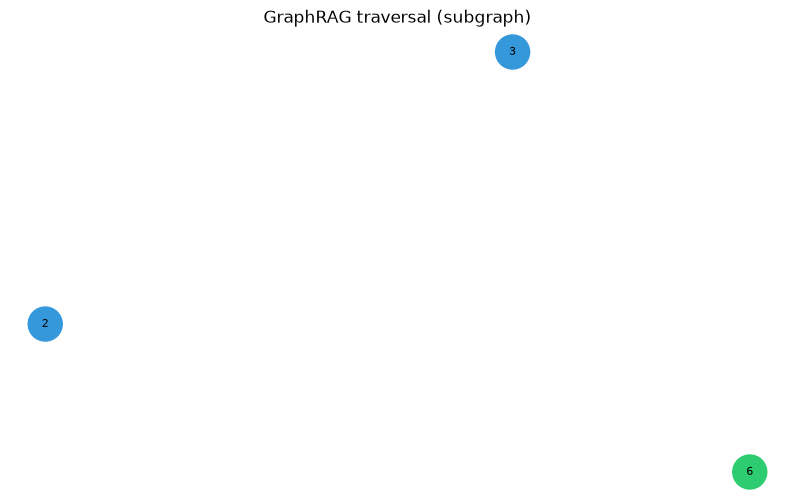

In [ ]:
import matplotlib.pyplot as plt


def visualize_traversal(kg: nx.Graph, visited: list[int], main_path: list[int]) -> None:
    if not visited:
        print("no visited nodes")
        return

    sub = kg.subgraph(visited).copy()
    pos = nx.spring_layout(sub, seed=7)

    plt.figure(figsize=(10, 6))

    # edges
    widths = []
    for u, v in sub.edges():
        info: EdgeInfo = sub.edges[u, v]["info"]
        widths.append(1.0 + 3.5 * info.weight)
    nx.draw_networkx_edges(sub, pos, alpha=0.35, width=widths)

    # nodes
    node_colors = []
    for n in sub.nodes():
        if n == main_path[0]:
            node_colors.append("#2ecc71")  # start
        elif n == main_path[-1]:
            node_colors.append("#e74c3c")  # end
        elif n in main_path:
            node_colors.append("#f1c40f")  # path
        else:
            node_colors.append("#3498db")

    nx.draw_networkx_nodes(sub, pos, node_color=node_colors, node_size=600)
    nx.draw_networkx_labels(sub, pos, font_size=8)

    # path edges overlay
    if len(main_path) >= 2:
        path_edges = list(zip(main_path[:-1], main_path[1:]))
        nx.draw_networkx_edges(sub, pos, edgelist=path_edges, width=4.0, alpha=0.9, edge_color="#f39c12")

    plt.axis("off")
    plt.title("GraphRAG traversal (subgraph)")
    plt.show()


visualize_traversal(kg, result["visited_nodes"], result["main_path"])